In [5]:
import os
from machinable import get

get('machinable.index', os.environ['STORAGE']).__enter__()

machinable.index [8a726b]

In [6]:
# non-surrogate baseline
interface = get('interface.experiment.modeling.baseline')

In [17]:
# download data
if not os.path.isfile(interface.components[0].output_filepath):
    with get("interface.storage.globus"):
        with get("interface.execution.download"):
            interface.launch()


In [11]:
# display status of optimization
interface.progress()

CA1_SCA_neuron::O:-/C:-/S:-
78211  /  138900  ( 56 %)

CA1_IVY_neuron::O:-/C:-/S:-
92243  /  138900  ( 66 %)

CA1_PVBC_neuron::O:-/C:-/S:-
78618  /  138900  ( 57 %)

CA1_CCKBC_neuron::O:-/C:-/S:-
80107  /  138900  ( 58 %)

CA1_AAC_neuron::O:-/C:-/S:-
94958  /  138900  ( 68 %)

CA1_BS_neuron::O:-/C:-/S:-
106912  /  138900  ( 77 %)

CA1_OLM_neuron::O:-/C:-/S:-
98182  /  138900  ( 71 %)

CA1_NGFC_neuron::O:-/C:-/S:-
98965  /  139000  ( 71 %)

CA1_IS_neuron::O:-/C:-/S:-
73681  /  138800  ( 53 %)



In [10]:
# get best
best = {}
for i, c in enumerate(interface.components):
    population = c.label().split('_')[1]
    print(f"{population} [{i}]")
    best[population] = c.get_best(
        sort_by="-np.std(y, axis=1)", 
        epsilon="auto" # use epsilon-comparison, set to None for strict comparison
    )
    print('y*')
    print(best[population]['y'])
    print('---')

SCA [0]
y*
   rn_error  tau_error  fI_error  spike_amplitude_error
0       0.0   2.503829       1.0                    0.0
---
IVY [1]
y*
   rn_error  tau_error  fI_error  spike_amplitude_error
0       0.0        0.0       0.5                    0.0
---
PVBC [2]
y*
   rn_error  tau_error  fI_error  spike_amplitude_error
0       0.0        0.0       0.0                    0.0
---
CCKBC [3]
y*
        rn_error  tau_error  fI_error  spike_amplitude_error
0   26665.486328   2.137123      0.50               0.272048
1   16574.529297   6.612656      0.50              44.622444
2    8282.901367   0.000000      0.25              56.800926
3    7023.012695   0.000000      1.50               0.000000
4    3474.420654   0.191903      4.00               0.000000
5     903.804016   0.000000      1.50              11.242075
6     742.747803  11.721272      1.50               0.741645
7     685.294495   8.571701     12.50             380.852234
8     537.892273  16.269386    235.00               0.00

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

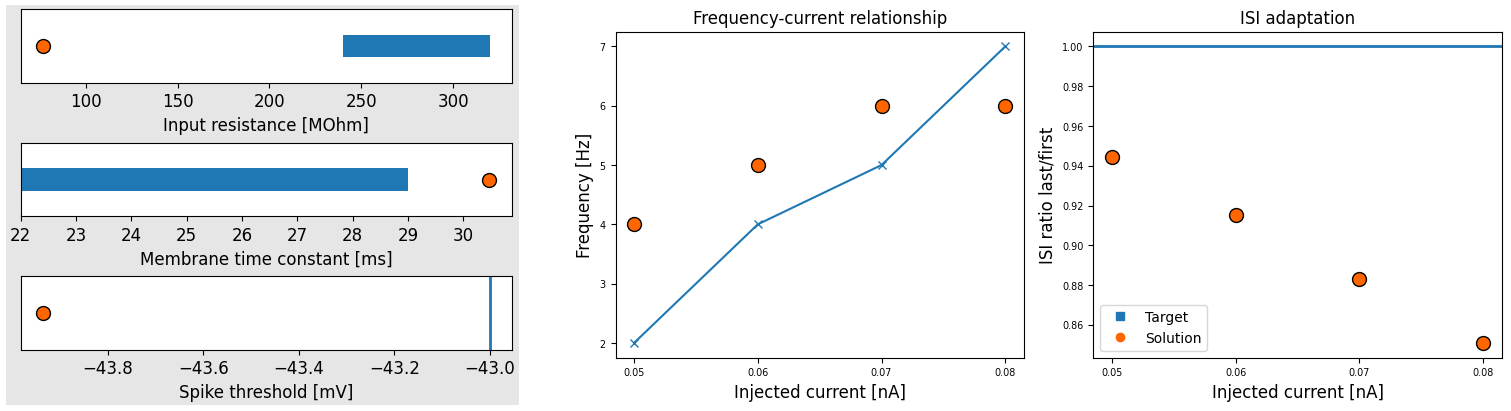

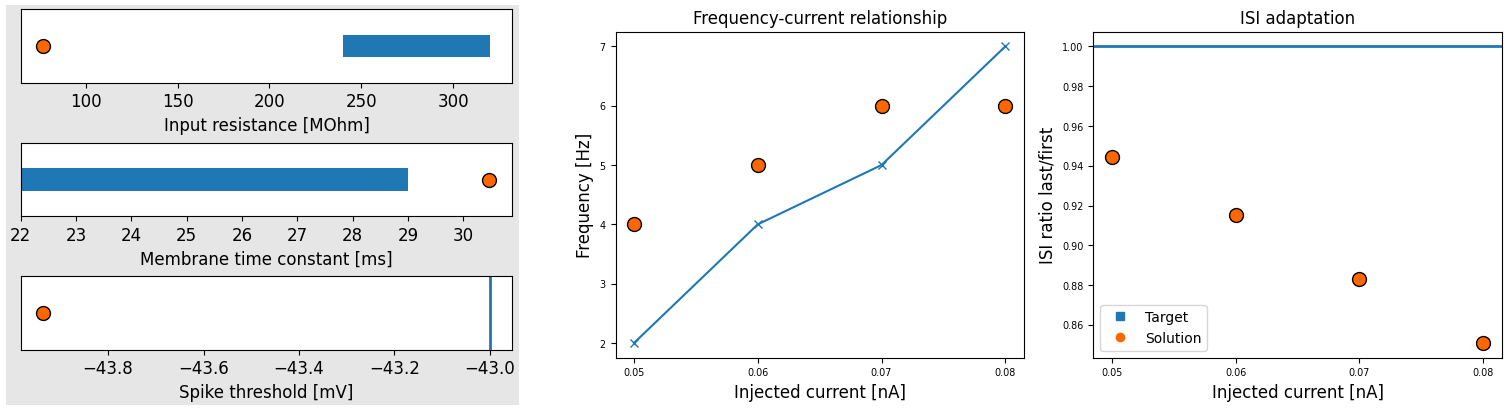

In [13]:
# inspect single datapoint

cckbc = interface.components[3]

cckbc.plot_features(best['CCKBC']['f'].iloc[0])

NEURON: Couldn't find: rn.hoc
 near line 0
 ^


	1 


INFO:interface.sopt_modeling:{'Ltotal': 28.40092658996582,
 'cm_ratio': 4.353466033935547,
 'dend_beta_Caconc': 0.009999999776482582,
 'dend_d_Caconc': 3.7345924377441406,
 'dend_g_pas': 0.0001867823302745819,
 'dend_gmax_Ca': 0.36491841077804565,
 'dend_gmax_KCa': 1.0,
 'e_pas': -62,
 'gc': 44.97706985473633,
 'global_cm': 3.0,
 'global_diam': 10.0,
 'pp': 0.23754265904426575,
 'soma_g_pas': 0.0,
 'soma_gmax_K': 0.8022789359092712,
 'soma_gmax_Na': 0.4224260747432709}
INFO:interface.sopt_modeling:initial_v_error: -1.8491439220724715e-05
INFO:interface.sopt_modeling:ic_constant0: -0.01051794373097356
INFO:interface.sopt_modeling:ic_constant: -0.02939414605498314
INFO:interface.sopt_modeling:mean initial vm constraint: 1
INFO:interface.sopt_modeling:soma ek = -89.7063966755447 ena = 60.43883162163455
INFO:interface.sopt_modeling:dend ek = -89.7063966755447 eca = 162.58785237096964
INFO:interface.sopt_modeling:soma nao = 145.0 ko = 5.0
INFO:interface.sopt_modeling:dend ki = 145.0 ko = 5.

PRN_nrn[0].soma { nseg=1  L=6.74643  Ra=2900.96
	/*location 0 attached to cell 0*/
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=13.0604}
	insert pas { g_pas=0 e_pas=-62}
	insert constant { ic_constant=-0.0293941}
	insert Na_PR { gmax_Na_PR=0.422426}
	insert K_PR { gmax_K_PR=0.802279}
	insert Na_conc_PR { d_Na_conc_PR=0.2 nao0_Na_conc_PR=145 nai0_Na_conc_PR=15 beta_Na_conc_PR=0.075}
	insert na_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_PR=5 ki0_K_conc_PR=145 beta_K_conc_PR=0.075}
	insert k_ion {}
}
PRN_nrn[0].dend { nseg=1  L=21.6545  Ra=281.575
	PRN_nrn[0].soma connect PRN_nrn[0].dend (0), 1
	/* First segment only */
	insert morphology { diam=10}
	insert capacitance { cm=3}
	insert pas { g_pas=0.000186782 e_pas=-62}
	insert Ca_PR { gmax_Ca_PR=0.364918}
	insert KCa_PR { gmax_KCa_PR=1}
	insert Ca_conc_PR { cai0_Ca_conc_PR=1e-05 d_Ca_conc_PR=3.73459 beta_Ca_conc_PR=0.01}
	insert ca_ion {}
	insert K_conc_PR { d_K_conc_PR=0.2 ko0_K_conc_PR=5 ki

INFO:interface.sopt_modeling:spikes: (0, 3, -45.763568661336485, array([(28.25938599, 503.64, 74.02295465, 500.01, 504.13),
       (26.85893247, 704.09, 72.62250113, 504.14, 704.53),
       (26.73406642, 873.37, 72.49763508, 704.54, 873.81)],
      dtype=[('Vpeak', '<f8'), ('Tpeak', '<f8'), ('amplitude', '<f8'), ('T0', '<f8'), ('T1', '<f8')]))
INFO:interface.sopt_modeling:dend ki min/max: 144.89437668791086 / 145.0


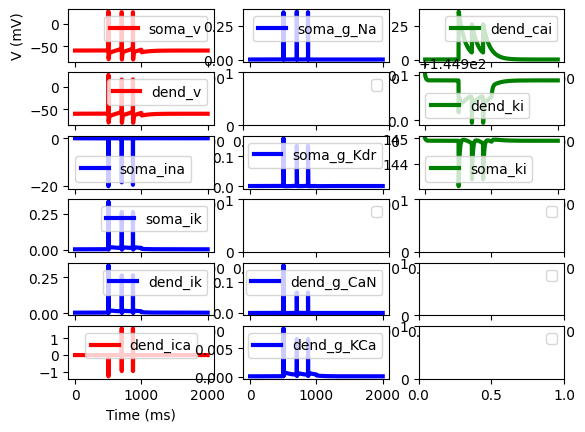

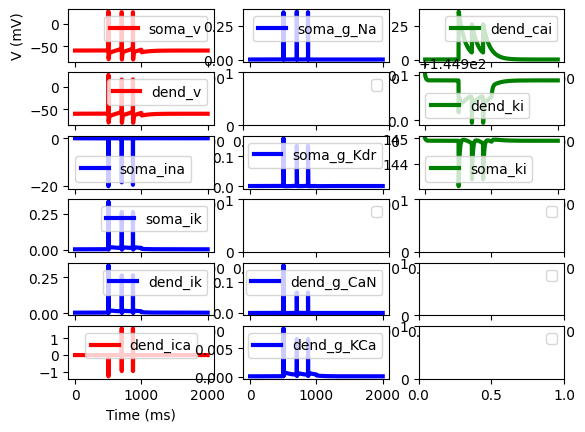

In [14]:
cckbc.plot_iclamp()